# FORGE Analytics — Variance Engine
### Notebook 3 of 4 · Antonio Heredia · FP&A Portfolio

One of the core responsibilities in FP&A is explaining why actual results 
differed from the plan. This notebook automates that process for FORGE — 
pulling budget vs actual data from the database, calculating variances by 
department, and flagging anything that exceeds a ±10% materiality threshold.

The goal is to replace manual spreadsheet work with a repeatable, 
data-driven process.

In [1]:
# Import libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np

# Connect to FORGE database
conn = sqlite3.connect('../data/forge.db')

# Load budget table
df = pd.read_sql_query("""
    SELECT
        month,
        department,
        budgeted_opex,
        actual_opex,
        variance
    FROM budget
    ORDER BY month, department
""", conn)

df['month'] = pd.to_datetime(df['month'])

print("Budget data loaded successfully")
print(f"Rows          : {len(df):,}")
print(f"Departments   : {df['department'].nunique()} — {sorted(df['department'].unique())}")
print(f"Date range    : {df['month'].min().strftime('%b %Y')} to {df['month'].max().strftime('%b %Y')}")
print(f"Total budgeted: ${df['budgeted_opex'].sum():,.0f}")
print(f"Total actual  : ${df['actual_opex'].sum():,.0f}")
print()
print(df.head(10).to_string(index=False))

Budget data loaded successfully
Rows          : 135
Departments   : 5 — ['Engineering', 'G&A', 'Operations', 'R&D', 'Sales & Marketing']
Date range    : Jan 2024 to Mar 2026
Total budgeted: $9,008,100
Total actual  : $9,419,300

     month        department  budgeted_opex  actual_opex  variance
2024-01-01       Engineering        75000.0      85300.0   10300.0
2024-01-01               G&A        45000.0      41700.0   -3300.0
2024-01-01        Operations        38000.0      35500.0   -2500.0
2024-01-01               R&D        70000.0      62100.0   -7900.0
2024-01-01 Sales & Marketing        85000.0      76000.0   -9000.0
2024-02-01       Engineering        75400.0      81300.0    5900.0
2024-02-01               G&A        45200.0      44100.0   -1100.0
2024-02-01        Operations        38200.0      44400.0    6200.0
2024-02-01               R&D        70400.0      68500.0   -1900.0
2024-02-01 Sales & Marketing        85400.0      78400.0   -7000.0


## Step 1 — Variance calculation

For each department and month, I calculate two things:
- Variance in dollars (actual minus budget)
- Variance as a percentage of budget

Positive variance means the department spent more than planned. 
Negative means they came in under budget. I flag anything beyond 
±10% as material — meaning it needs explanation, not just a note.

In [2]:
MATERIALITY_THRESHOLD = 0.10  # 10%

# Recalculate variance from source columns for consistency
df['variance_dollars'] = df['actual_opex'] - df['budgeted_opex']
df['variance_pct']     = df['variance_dollars'] / df['budgeted_opex']

# Flag months where a department breaches the materiality threshold
df['flag'] = df['variance_pct'].abs() > MATERIALITY_THRESHOLD
df['flag_direction'] = np.where(
    ~df['flag'], 'On track',
    np.where(df['variance_pct'] > 0, 'Over budget', 'Under budget')
)

# Department-level aggregation
dept_summary = df.groupby('department').agg(
    total_budgeted = ('budgeted_opex',   'sum'),
    total_actual   = ('actual_opex',     'sum'),
    total_variance = ('variance_dollars', 'sum'),
    avg_variance_pct = ('variance_pct',  'mean'),
    months_over    = ('flag_direction',  lambda x: (x == 'Over budget').sum()),
    months_under   = ('flag_direction',  lambda x: (x == 'Under budget').sum()),
    months_total   = ('month',           'count'),
).reset_index()

dept_summary['total_variance_pct'] = dept_summary['total_variance'] / dept_summary['total_budgeted']
dept_summary['flag'] = dept_summary['total_variance_pct'].abs() > MATERIALITY_THRESHOLD

print("Department variance summary (full period):")
display_cols = ['department', 'total_budgeted', 'total_actual', 'total_variance', 'total_variance_pct', 'months_over', 'months_under']
fmt = dept_summary[display_cols].copy()
fmt['total_budgeted']    = fmt['total_budgeted'].map('${:,.0f}'.format)
fmt['total_actual']      = fmt['total_actual'].map('${:,.0f}'.format)
fmt['total_variance']    = fmt['total_variance'].map('${:+,.0f}'.format)
fmt['total_variance_pct'] = fmt['total_variance_pct'].map('{:+.1%}'.format)
print(fmt.to_string(index=False))

Department variance summary (full period):
       department total_budgeted total_actual total_variance total_variance_pct  months_over  months_under
      Engineering     $2,158,600   $2,340,000      $+181,400              +8.4%           13             1
              G&A     $1,294,900   $1,326,700       $+31,800              +2.5%            8             1
       Operations     $1,093,600   $1,090,500        $-3,100              -0.3%            3             0
              R&D     $2,014,700   $2,121,600      $+106,900              +5.3%           11             3
Sales & Marketing     $2,446,300   $2,540,500       $+94,200              +3.9%            7             1


## Step 2 — Materiality flags

Not every variance is worth investigating. A $200 overage on a 
$500,000 budget is noise. A $50,000 overage on the same budget 
is a conversation with the department head.

The ±10% threshold filters out the noise and surfaces the variances 
that actually matter for management reporting.

In [3]:
# Month-level flags — which department-months breached the threshold?
flagged = df[df['flag']].copy()
flagged_display = flagged[['month', 'department', 'budgeted_opex', 'actual_opex', 'variance_dollars', 'variance_pct', 'flag_direction']].copy()
flagged_display['month']           = flagged_display['month'].dt.strftime('%b %Y')
flagged_display['budgeted_opex']   = flagged_display['budgeted_opex'].map('${:,.0f}'.format)
flagged_display['actual_opex']     = flagged_display['actual_opex'].map('${:,.0f}'.format)
flagged_display['variance_dollars'] = flagged_display['variance_dollars'].map('${:+,.0f}'.format)
flagged_display['variance_pct']    = flagged_display['variance_pct'].map('{:+.1%}'.format)

total_months = len(df)
flagged_count = len(flagged)
over_count  = (flagged['flag_direction'] == 'Over budget').sum()
under_count = (flagged['flag_direction'] == 'Under budget').sum()

print(f"Materiality threshold : ±{MATERIALITY_THRESHOLD:.0%}")
print(f"Total dept-months     : {total_months}")
print(f"Flagged dept-months   : {flagged_count} ({flagged_count/total_months:.0%} of total)")
print(f"  → Over budget       : {over_count}")
print(f"  → Under budget      : {under_count}")
print()
print("Flagged department-months:")
print(flagged_display.to_string(index=False))

Materiality threshold : ±10%
Total dept-months     : 135
Flagged dept-months   : 48 (36% of total)
  → Over budget       : 42
  → Under budget      : 6

Flagged department-months:
   month        department budgeted_opex actual_opex variance_dollars variance_pct flag_direction
Jan 2024       Engineering       $75,000     $85,300         $+10,300       +13.7%    Over budget
Jan 2024               R&D       $70,000     $62,100          $-7,900       -11.3%   Under budget
Jan 2024 Sales & Marketing       $85,000     $76,000          $-9,000       -10.6%   Under budget
Feb 2024        Operations       $38,200     $44,400          $+6,200       +16.2%    Over budget
Mar 2024       Engineering       $75,800     $88,700         $+12,900       +17.0%    Over budget
Mar 2024               R&D       $70,700     $62,800          $-7,900       -11.2%   Under budget
Apr 2024               G&A       $45,700     $50,700          $+5,000       +10.9%    Over budget
Apr 2024               R&D       $71

## Step 3 — Budget vs actual by department

Total budgeted vs actual spend across all 27 months, by department. 
The gap between the bars shows cumulative overspend or underspend 
for each cost center.

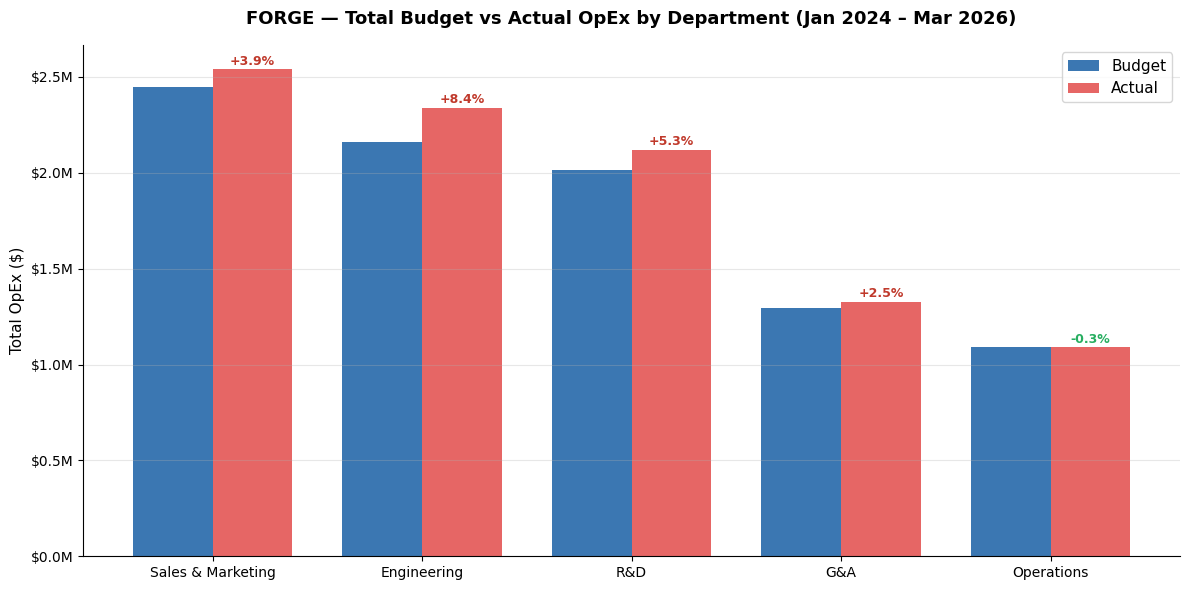

Chart saved to data/variance_by_dept.png


In [4]:
dept_order = dept_summary.sort_values('total_budgeted', ascending=False)['department'].tolist()
plot_data  = dept_summary.set_index('department').loc[dept_order]

x     = np.arange(len(dept_order))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))

bars_budget = ax.bar(x - width/2, plot_data['total_budgeted'], width,
                     label='Budget', color='#185FA5', alpha=0.85)
bars_actual = ax.bar(x + width/2, plot_data['total_actual'],   width,
                     label='Actual', color='#E24B4A', alpha=0.85)

# Variance % labels above each actual bar
for i, (dept, row) in enumerate(plot_data.iterrows()):
    pct   = row['total_variance_pct']
    color = '#C0392B' if pct > 0 else '#27AE60'
    label = f"{pct:+.1%}"
    ax.text(i + width/2, row['total_actual'] + 8000,
            label, ha='center', va='bottom', fontsize=9,
            fontweight='bold', color=color)

ax.set_title('FORGE — Total Budget vs Actual OpEx by Department (Jan 2024 – Mar 2026)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(dept_order, fontsize=10)
ax.set_ylabel('Total OpEx ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1e6:.1f}M'))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/variance_by_dept.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to data/variance_by_dept.png")

## Step 4 — Average monthly variance by department

Instead of looking at every month, this chart shows the average 
monthly variance percentage for each department. It makes it easy 
to see which departments are consistently over or under budget 
rather than just having one bad month.

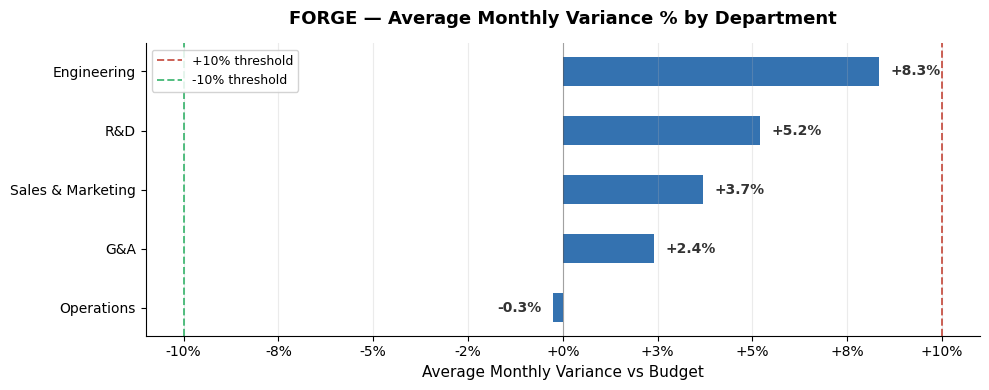

Chart saved to data/variance_avg_by_dept.png


In [5]:
# Average monthly variance % per department, ranked highest to lowest overspend
avg_var = (
    df.groupby('department')['variance_pct']
    .mean()
    .sort_values(ascending=True)   # ascending so worst overspend appears at top
    .reset_index()
)
avg_var.columns = ['department', 'avg_variance_pct']

fig, ax = plt.subplots(figsize=(10, 4))

bar_colors = [
    '#C0392B' if v > MATERIALITY_THRESHOLD else
    '#27AE60' if v < -MATERIALITY_THRESHOLD else
    '#185FA5'
    for v in avg_var['avg_variance_pct']
]

bars = ax.barh(
    avg_var['department'],
    avg_var['avg_variance_pct'],
    color=bar_colors,
    height=0.5,
    alpha=0.88
)

# ±10% threshold lines
ax.axvline( MATERIALITY_THRESHOLD, color='#C0392B', linewidth=1.4,
            linestyle='--', alpha=0.8, label='+10% threshold')
ax.axvline(-MATERIALITY_THRESHOLD, color='#27AE60', linewidth=1.4,
            linestyle='--', alpha=0.8, label='-10% threshold')
ax.axvline(0, color='#333333', linewidth=0.8, alpha=0.4)

# Value labels at end of each bar
for bar, val in zip(bars, avg_var['avg_variance_pct']):
    offset = 0.003 if val >= 0 else -0.003
    ha     = 'left'  if val >= 0 else 'right'
    ax.text(
        val + offset, bar.get_y() + bar.get_height() / 2,
        f'{val:+.1%}',
        va='center', ha=ha, fontsize=10, fontweight='bold',
        color='#333333'
    )

ax.set_title('FORGE — Average Monthly Variance % by Department',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Average Monthly Variance vs Budget', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.0%}'))
ax.legend(fontsize=9, framealpha=0.85)
ax.grid(axis='x', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/variance_avg_by_dept.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to data/variance_avg_by_dept.png')

## Step 6 — Monthly variance heatmap

This shows variance percentage by department and month in a grid. 
Red cells are over budget, green are under. It makes it easy to 
spot patterns, if a department consistently over budget, or did 
something unusual happen in one specific month?

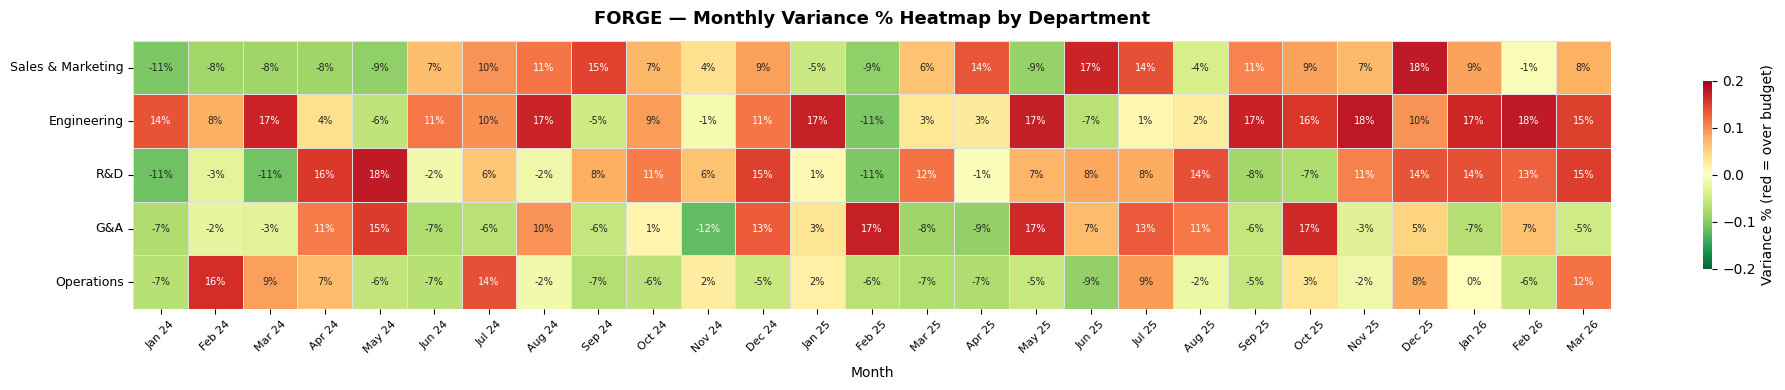

Heatmap saved to data/variance_heatmap.png


In [6]:
import seaborn as sns

# Pivot: departments as rows, months as columns
heatmap_data = df.pivot_table(
    index='department',
    columns='month',
    values='variance_pct'
)
heatmap_data.columns = pd.to_datetime(heatmap_data.columns).strftime('%b %y')
heatmap_data = heatmap_data.loc[dept_order]   # consistent dept ordering

fig, ax = plt.subplots(figsize=(20, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0%',
    cmap='RdYlGn_r',
    center=0,
    vmin=-0.20,
    vmax=0.20,
    linewidths=0.4,
    linecolor='#e0e0e0',
    ax=ax,
    annot_kws={'size': 7},
    cbar_kws={'label': 'Variance % (red = over budget)', 'shrink': 0.7}
)

ax.set_title('FORGE — Monthly Variance % Heatmap by Department',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=10, labelpad=8)
ax.set_ylabel('', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('../data/variance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved to data/variance_heatmap.png")

## Key findings

Every department ran over budget across the full period, but the 
magnitude varies significantly. Engineering had the largest cumulative 
overspend at +8.4% on average and it was over budget in 13 out of 
27 months. That kind of consistency usually means the budget itself 
is too low, not that spending is out of control.

Operations is the only department that came in under budget on average 
at -0.3%. That's worth noting but also worth questioning, underspend 
in operations can sometimes mean planned work wasn't done.

G&A and R&D are the most budget-disciplined departments, with the 
smallest average variances. Sales & Marketing is trending worse over 
time with recent months show higher variance than earlier periods, which 
could indicate the team is ramping spend ahead of results.

Overall FORGE's cost discipline is reasonable, but Engineering needs 
a budget reforecast. Running 8% over plan every month for two years 
means the annual budget is no longer a useful management tool for that team.